# SOLUTIONS AND EXPLANATIONS FOR LESSON 1: MATRIX FOR AI (20/6/2026) HOMEWORK - USING TEXTS

## PREPARATION FOR BOTH EXERCISES: TRANSFORM TEXTS TO VECTORS AND MATRIXES

Import numpy lib and create a list of 8 sentences to transform to vectors

In [121]:
import numpy as np
sentence = ["i love you", 
            "this house is big",
            "you are beautiful",
            "that will do",
            "you are welcome", 
            "how are you", 
            "what is your name", 
            "i play badminton"]

extract each separate word from every sentence and then sort them in alphabet order

In [122]:
word = []
for s in sentence:
    for w in s.lower().split():
        word.append(w)
word.sort()
print(word)

['are', 'are', 'are', 'badminton', 'beautiful', 'big', 'do', 'house', 'how', 'i', 'i', 'is', 'is', 'love', 'name', 'play', 'that', 'this', 'welcome', 'what', 'will', 'you', 'you', 'you', 'you', 'your']


This method uses list, but some words can be duplicated so we must change to set, then sorted() will give us back a list that can be extracted using index.

In [137]:
vocab = sorted({w for s in sentence for w in s.lower().split()})
print(vocab)
print(len(vocab))

['are', 'badminton', 'beautiful', 'big', 'do', 'house', 'how', 'i', 'is', 'love', 'name', 'play', 'that', 'this', 'welcome', 'what', 'will', 'you', 'your']
19


building a function to transform these words to vectors

In [124]:
def to_vectors(s):
    v = np.zeros(len(vocab)) # an array all 0 with length of word list above
    for w in s.lower().split():
        v[vocab.index(w)] += 1 
    return v
matrix = np.array([to_vectors(s) for s in sentence], dtype=int)
print(matrix)
print(matrix.shape)

[[0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0]
 [0 0 0 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0]
 [1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0]
 [1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 1]
 [0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0]]
(8, 19)


Here, 8 sentences are separately transformed to 8 vectors (each with 19 dims or 19 words in total) which makes a 8x19 matrix.
- 8 rows are 8 sentences whose "1" stands at the index corresponds to a word in the sorted word list above
- Each column represents the frequency that each word appears in each sentence. for ex, the first column represents for word[0] ('are') that 'are' appears in sentence 3,5 and 6 one time.

## EXERCISE 1: CALCULATE THE SIMILARITY

### Basic operation: Mean-centering

We take the mean of each column

In [125]:
col_mean = np.mean(matrix, axis=0, keepdims=True) # axis=0 means that we are taking average by columns (=1 is for rows)
print(col_mean)
print(col_mean.shape)

[[0.375 0.125 0.125 0.125 0.125 0.125 0.125 0.25  0.25  0.125 0.125 0.125
  0.125 0.125 0.125 0.125 0.125 0.5   0.125]]
(1, 19)


first column average = 3/8 = 0.375. Here we keep the original dims with 19 columns

Now, mean centering

In [126]:
centered_matrix = matrix - col_mean
print(centered_matrix)
print(centered_matrix.shape)

[[-0.375 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125  0.75  -0.25   0.875
  -0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125  0.5   -0.125]
 [-0.375 -0.125 -0.125  0.875 -0.125  0.875 -0.125 -0.25   0.75  -0.125
  -0.125 -0.125 -0.125  0.875 -0.125 -0.125 -0.125 -0.5   -0.125]
 [ 0.625 -0.125  0.875 -0.125 -0.125 -0.125 -0.125 -0.25  -0.25  -0.125
  -0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125  0.5   -0.125]
 [-0.375 -0.125 -0.125 -0.125  0.875 -0.125 -0.125 -0.25  -0.25  -0.125
  -0.125 -0.125  0.875 -0.125 -0.125 -0.125  0.875 -0.5   -0.125]
 [ 0.625 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.25  -0.25  -0.125
  -0.125 -0.125 -0.125 -0.125  0.875 -0.125 -0.125  0.5   -0.125]
 [ 0.625 -0.125 -0.125 -0.125 -0.125 -0.125  0.875 -0.25  -0.25  -0.125
  -0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125  0.5   -0.125]
 [-0.375 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.25   0.75  -0.125
   0.875 -0.125 -0.125 -0.125 -0.125  0.875 -0.125 -0.5    0.875]
 [-0.375  0.875 -0.125 -0.125 -0.1

Numpy will automatically copy the col_mean matrix above to 7 more rows to make a 8x19 matrix (same shape as matrix). This is called broadcasting in Numpy.  
Subtracting each entry with the average will make each column's mean = 0.

In [127]:
column_mean = np.mean(centered_matrix, axis=0, keepdims=True)
print(column_mean)

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


### Cosine similarity

is basically comparing the value of cosine between 2 vectors:
- ~1 means they are highly related

In [128]:
def cosine_similarity(X, Y = None):
    if Y is None:
        Y = X
    
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True) # divided by the length (norm) of itself or Vector Normalization
    Yn = Y / np.linalg.norm(Y, axis=1, keepdims=True)

    return Xn @ Yn.T

This function corresponds to the formula: $cos = \frac{u \times v}{||u|| \times ||v||}$

In [129]:
# Calculate with sentence 1 and 2
print(f'cosine similarity of sentence 1 and 2 is: {cosine_similarity(matrix[0:1], matrix[1:2])}')

# Calculate with sentence 1 and 8
print(f'cosine similarity of sentence 1 and 8 is: {cosine_similarity(matrix[0:1], matrix[7:8])}')

# Calculate with sentence 3 and 5
print(f'cosine similarity of sentence 3 and 5 is: {cosine_similarity(matrix[2:3], matrix[4:5])}')


cosine similarity of sentence 1 and 2 is: [[0.]]
cosine similarity of sentence 1 and 8 is: [[0.33333333]]
cosine similarity of sentence 3 and 5 is: [[0.66666667]]


sentence 1 and 2 have 0/3 identical words. Cos = 0 means 2 vectors are perpendicular and are not related  
whereas 1 and 8 have 1/3 and 3 and 5 have 2/3

### Word Embedding - Semantic research

The to_vector method above is just a way to vectorize a sentence to count the appearance of words. It does not account for the semantic or meaning of them.  
For example, 'I go by bike' and 'I ride a bicycle' would end up having a very ~0 cosine value as the function doesn't know that bike and bicycle are synonyms or go by and ride is almost the same.


This is where Semantic search is introduced.  
First, engineers create a vector that has 100-768 dims (most LLMs now choose 768) representing for a separate word. Each dim is a randomly generated number which show a property of that word.  
Then the model will go through 2 games: masked language modelling and next sentence prediction to adjust those numbers so that each word will have its own set and the relations between vocabs are precise. For ex, 'cat' and 'dog' will be closed not 'cat' and 'car'.  
Finally, when users input, the model will use cosine similarity to find the top-related words in terms of context and meaning.

The same goes for sentences. Here we will simulate the algorithm by generating a random 1x768 matrix for each sentence.

In [130]:
train = np.random.rand(len(sentence), 768)
print(train)
print(train.shape)

[[0.67018427 0.18627569 0.53029241 ... 0.10960073 0.3492348  0.0744099 ]
 [0.59113617 0.01166645 0.72037439 ... 0.22603893 0.7278478  0.57883484]
 [0.2973987  0.82173818 0.45699201 ... 0.30611097 0.27508863 0.95812769]
 ...
 [0.96840806 0.75352304 0.41648659 ... 0.8237225  0.58212466 0.00776142]
 [0.91443468 0.36469457 0.5815939  ... 0.93764904 0.17268436 0.86255408]
 [0.49488009 0.09196319 0.06300255 ... 0.50432523 0.2010736  0.50861121]]
(8, 768)


create a semantic search function

In [131]:
def search(query, top_k=3):
    q = np.random.rand(1, 768) # transform the user input also to a 1x768

    cos = cosine_similarity(q, train) # thanks to broadcasting, numpy will calculate the cosine similarity of q to each of our sentence
    cos = cos.flatten() # change to 1D (array) for easier cals
    print(cos) # will be random each run as we choose random 768 numbers

    #In order to sort from small to big cos value without losing track of which value correspond to which sentence -> use argsort
    cos_idx_sort = np.argsort(cos)
    print(cos_idx_sort)

    T_k = cos_idx_sort[-top_k:][::-1] # Take out top 3 and then sort backwards to get big -> small
    print(T_k)

    return [(sentence[x], round(float(cos[x]), 3)) for x in T_k]

search('love you')

[0.75546918 0.76294295 0.77640851 0.76179081 0.76118691 0.77495003
 0.76884351 0.76795008]
[0 4 3 1 7 6 5 2]
[2 5 6]


[('you are beautiful', 0.776),
 ('how are you', 0.775),
 ('what is your name', 0.769)]

In [132]:
search('skibidi toilet')

[0.75088273 0.75296281 0.75161354 0.75030707 0.74948919 0.75097276
 0.74938112 0.74934465]
[7 6 4 3 0 5 2 1]
[1 2 5]


[('this house is big', 0.753),
 ('you are beautiful', 0.752),
 ('how are you', 0.751)]

The most related pairs will have the cosine value ~1.  
The results are not close and correct as we think, cuz all the 768 numbers are random and our word-embedding is nowhere near the reality.

## EXERCISE 2: LINEAR TRANSFORMATION & SVD

SVD is a way to decompose a matrix into 3 components that can show the variance of data (referencing our major assignment in Linear Algebra - Randomized PCA).  
centered_matrix = $U \Sigma V^\top$

In [133]:
U, Sigma, Vt = np.linalg.svd(centered_matrix)
print(U.shape)
print(Sigma.shape)
print(Vt.shape)

(8, 8)
(8,)
(19, 19)


Then we truncate each components down to 2 dims

In [134]:
U_k = U[:,:2]
print(U_k)
print(U_k.shape)

Sigma_k = Sigma[:2]
print(Sigma_k)
print(Sigma_k.shape)

[[ 0.16130518  0.32732684]
 [-0.50148896 -0.32732684]
 [ 0.37743107 -0.21821789]
 [-0.17181994  0.32732684]
 [ 0.37743107 -0.21821789]
 [ 0.37743107 -0.21821789]
 [-0.50148896 -0.32732684]
 [-0.11880051  0.65465367]]
(8, 2)
[2.45812499 2.        ]
(2,)


Here, we don't use Vt because if multiply, it will become the original with separate words.  
We just want to embed 8 sentences + 8 topics and their weights.

In [135]:
Sigma_k = np.diag(Sigma_k) # transform Sigma_k from 1D array to square matrix
sentence_embed = U_k @ Sigma_k
print(sentence_embed)

[[ 0.39650828  0.65465367]
 [-1.23272255 -0.65465367]
 [ 0.92777274 -0.43643578]
 [-0.42235489  0.65465367]
 [ 0.92777274 -0.43643578]
 [ 0.92777274 -0.43643578]
 [-1.23272255 -0.65465367]
 [-0.29202651  1.30930734]]


Now, each sentence has been cut down to 2 dims presenting their 2 most significant features/topics.  
We will sketch this to a graph to demonstrate.

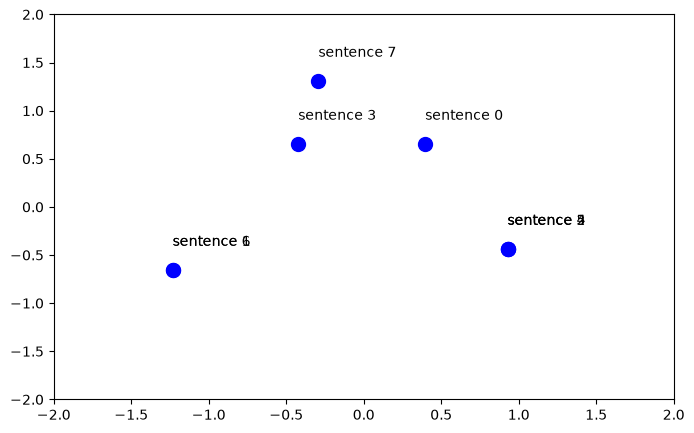

In [136]:
import matplotlib.pyplot as plt

x_coords = sentence_embed[:, 0] # first column
y_coords = sentence_embed[:, 1]

plt.figure(figsize = (8, 5))
plt.scatter(x_coords, y_coords, s=100, c='blue')
plt.xlim(-2, 2)
plt.ylim(-2, 2)
for i in range(len(sentence)):
    plt.text(x_coords[i], y_coords[i] + 0.25, f"sentence {i}")
